# Clustering of all data

Read in all necessary packages:

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import loompy
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
import random
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson

import scipy
import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_5281/284414565.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [404]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [3]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

k27_k4 = sns.blend_palette(['#6a51a3', '#9e9bc8', '#dadaeb','#c8e9c1','#75c477','#238b45'], as_cmap = True)
k4_k27 = sns.blend_palette(['#238b45', '#75c477', '#c8e9c1' ,'#dadaeb','#9e9bc8','#6a51a3' ], as_cmap = True)
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'


In [576]:
cols = ['grey','skyblue','orange','red']
cols2 = ['white','deepskyblue','orange','red','grey']

leg_dict2 = {'negative': 'grey','positive': 'skyblue','going up': 'orange','going down': 'red'}
coldict=dict(zip(list(pd.DataFrame([0,1,2,3,4]).astype('category')[0]), cols2))
leg_dict = {'negative': 'white', 'positive': 'deepskyblue', 'going up': 'orange', 'going down': 'red'}

## formulas

In [299]:
pseudo = []
def bintable(df, stepsize):    
    df = df.sort_values(by = ['hour','pseudotime'],ascending=True)
    df['order'] = list(range(0,len(df)))
    df['steps'] = df['order'].apply(lambda x: np.floor(x/stepsize))
    binned_table_mean = {}
    binned_table_sum = {}
    celltype = []
    for step in df['steps'].unique():
        binned_table_mean[step] = df[df['steps'] == step].mean(numeric_only=True)
        binned_table_sum[step] = df[df['steps'] == step].sum(numeric_only=True)
        celltype.append(df[df['steps'] == step]['hour'].value_counts().sort_values(ascending=False).index[0])
    binned_pseudo = pd.DataFrame(pd.DataFrame(binned_table_mean).T['pseudotime'])
    binned_pseudo['celltype'] = celltype
    binned_final_mean = pd.DataFrame(binned_table_mean).T.drop(['order','steps','pseudotime'],axis = 1)
    binned_final_sum = pd.DataFrame(binned_table_sum).T.drop(['order','steps','pseudotime'],axis = 1)
    binned_pseudo = binned_pseudo.iloc[:-1,:]
    binned_final_mean = binned_final_mean.iloc[:-1,:]
    binned_final_sum = binned_final_sum.iloc[:-1,:]
    return binned_pseudo, binned_final_mean, binned_final_sum

In [300]:
def gene_ttest(b_df, mean = 2.5, fold = 1.5, pv = 2.3, cutoff = 10):
    start = np.log2((b_df.iloc[0:cutoff])+1)
    stop = np.log2((b_df.iloc[-cutoff:])+1)
    testout = pd.Series(index=start.columns, dtype='float')
    for gene in start.columns:
        s , p = stats.ttest_ind(start[gene],stop[gene])
        testout[gene] = p
    testresults = pd.DataFrame(columns=['fold','p','state','mean'], index = start.columns)
    testresults['fold'] = (stop.mean(axis=0)-start.mean(axis=0))
    testresults['mean'] = (start.mean(axis=0)+stop.mean(axis=0))/2
    testresults['p'] = (-np.log10(testout)).fillna(1)
    testresults['state'] = 0
    testresults.loc[((testresults['mean'] > mean)),'state'] = 1
    testresults.loc[((abs(testresults['fold']) > fold)&(testresults['p'] > pv)&(testresults['mean'] > mean)),'state'] = 2
    
    for gene in list(testresults[(testresults['fold']  < 0 )  & (testresults['state']  == 2)].index):
        testresults.loc[gene, 'state'] = 3   
    
    return testresults

In [580]:
def makeStatesPlot(states_plot, aspect_ratio = 0.0005, coldict = coldict,xlabel=False):
    states_plot = states_plot.fillna(4)
    order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(states_plot))
    states_sorted = states_plot.iloc[order]

    fig, ax = plt.subplots(figsize=(6, len(states_plot) * aspect_ratio), ncols=1)
    pos = ax.imshow(states_sorted,interpolation='none', aspect='auto', 
                   cmap=LinearSegmentedColormap.from_list('cmap_lin', list( map(coldict.get, list(coldict.keys()))), N=len(list(coldict.keys()))))
    if xlabel == True:
        ax.set_xticklabels(['f','K27','K4'])
    else:
        ax.set_xticklabels([])
    #patchList = []
    #for key in leg_dict:
    #        data_key = mpatches.Patch(color=leg_dict[key], label=key)
    #        patchList.append(data_key)

    #plt.legend(handles=patchList, bbox_to_anchor=[1.6,0.95])
    ax.set_yticklabels([])
    plt.legend([],frameon=False)
    plt.show()

In [302]:
def makeLinePlotsLayers(df_k4,df_k27,df_rna, genes, title = '',legend = False,
                       ylim = [-0.05,0.85], figsize = (6,3)):
    plot_df = pd.concat([df_k4[genes], b_pseudo_k4], axis=1)
    plot_df['binned'] = (plot_df['pseudotime']).astype(int)
    plot_df = plot_df.melt(['pseudotime','binned'], var_name = 'gene')

    plot_df2 = pd.concat([df_k27[genes], b_pseudo_k27], axis=1)
    plot_df2['binned'] = (plot_df2['pseudotime']).astype(int)
    plot_df2 = plot_df2.melt(['pseudotime','binned'], var_name = 'gene')

    plot_df3 = pd.concat([df_rna[genes], b_pseudo_rna], axis=1)
    plot_df3['binned'] = (plot_df3['pseudotime']).astype(int)
    plot_df3 = plot_df3.melt(['pseudotime','binned'], var_name = 'gene')

    fig, ax = plt.subplots(figsize = figsize)
    ax = sns.lineplot(
        data=plot_df, 
        x='binned', y='value', ax=ax, color = Green)
    ax = sns.lineplot(
        data=plot_df2, 
        x='binned', y='value', ax=ax, color = Purple)
    ax = sns.lineplot(
        data=plot_df3, 
        x='binned', y='value', ax=ax, color = Orange)

    sns.despine()
    plt.title(str(title))
    plt.xlabel('')
    plt.ylabel('')

    leg_dict3 = {'RNA': Orange,
     'H3K27me3': Purple,
     'H3K4me3': Green}
    
    if legend == True:
        patchList = []
        for key in leg_dict3:
                data_key = mpatches.Patch(color=leg_dict3[key], label=key)
                patchList.append(data_key)
        plt.legend(handles=patchList, bbox_to_anchor=[1.4,0.9],frameon=False)
    else:
        plt.legend([],frameon=False)
    plt.ylim(ylim)
    plt.xlim([-0.2,32])
    ax.set_xticklabels([])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))
    plt.show()


In [9]:
from matplotlib.ticker import FormatStrFormatter
def makeLinePlotsStates(df_states, binned_df, pseudo_df, mark,
                       xlabel = 'pseudotime', ylabel = 'norm. counts',
                       legend = True):

    genes = list(df_states[(df_states[mark] == 0)].index)
    plot_df = pd.concat([binned_df[genes], pseudo_df], axis=1)
    plot_df['binned'] = (plot_df['pseudotime']).astype(int)
    plot_df = plot_df.melt(['pseudotime','binned'], var_name = 'gene')

    genes = list(df_states[(df_states[mark] == 1)].index)
    plot_df2 = pd.concat([binned_df[genes], pseudo_df], axis=1)
    plot_df2['binned'] = (plot_df2['pseudotime']).astype(int)
    plot_df2 = plot_df2.melt(['pseudotime','binned'], var_name = 'gene')

    genes = list(df_states[(df_states[mark] == 2)].index)
    plot_df3 = pd.concat([binned_df[genes], pseudo_df], axis=1)
    plot_df3['binned'] = (plot_df3['pseudotime']).astype(int)
    plot_df3 = plot_df3.melt(['pseudotime','binned'], var_name = 'gene')

    genes = list(df_states[(df_states[mark] == 3)].index)
    plot_df4 = pd.concat([binned_df[genes], pseudo_df], axis=1)
    plot_df4['binned'] = (plot_df4['pseudotime']).astype(int)
    plot_df4 = plot_df4.melt(['pseudotime','binned'], var_name = 'gene')

    fig,ax = plt.subplots(figsize = (6,3))
    ax = sns.lineplot(
        data=plot_df, 
        x='binned', y='value',ax=ax,color = cols[0])

    ax = sns.lineplot(
        data=plot_df2, 
        x='binned', y='value', ax=ax, color = cols[1])

    ax = sns.lineplot(
        data=plot_df3, 
        x='binned', y='value', ax=ax, color = cols[2])

    ax = sns.lineplot(
        data=plot_df4, 
        x='binned', y='value', ax=ax, color = cols[3])
    if legend == True:
        patchList = []
        for key in leg_dict2:
                data_key = mpatches.Patch(color=leg_dict2[key], label=key)
                patchList.append(data_key)
        plt.legend(handles=patchList, bbox_to_anchor=[1.4,0.9], frameon = False)
    else:
        plt.legend([], frameon = False)   

    sns.despine()
    plt.title('')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim([-0.05,0.85])
    plt.xlim([-0.2,32])
    ax.yaxis.set_major_formatter(FormatStrFormatter('%g'))

    plt.show()

## K4me3 TSS tables

In [31]:
tss_selection = pd.read_csv('../data/full_promoter_table_for_K4_based_selection.tsv',
                            index_col = False, header = None, sep = '\t')





/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_5281/22631508.py:1: DtypeWarning: Columns (0,8) have mixed types. Specify dtype option on import or set low_memory=False.
  tss_selection = pd.read_csv('../data/full_promoter_table_for_K4_based_selection.tsv',


In [86]:
tss_selection#.loc[:,[3,17]]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,10,100013130,100018130,Kitl:1,protein_coding,Kitl,main_an,2,10,100013130,100018130,154.0,160.0,170.0,125.0,279.0,167.0,1,1,1
1,10,100085556,100090556,Kitl:2,protein_coding,Kitl,other,2,10,100085556,100090556,14.0,4.0,10.0,4.0,20.0,2.0,2,0,0
2,10,100333176,100338176,Gm4301:1,protein_coding,Gm4301,main_an,1,10,100333176,100338176,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
3,10,100338336,100343336,Gm4302:1,protein_coding,Gm4302,main_an,1,10,100338336,100343336,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
4,10,100343472,100348472,Gm4303:1,protein_coding,Gm4303,main_an,1,10,100343472,100348472,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39696,Y,9199690,9204690,Gm21721:1,protein_coding,Gm21721,main_an,1,Y,9199690,9204690,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
39697,Y,9344684,9349684,Gm21812:1,protein_coding,Gm21812,main_an,1,Y,9344684,9349684,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1
39698,Y,935283,940283,Kdm5d:3,protein_coding,Kdm5d,other,3,Y,935283,940283,0.0,0.0,0.0,0.0,0.0,0.0,3,0,0
39699,Y,9413648,9418648,Gm21874:1,protein_coding,Gm21874,main_an,1,Y,9413648,9418648,0.0,0.0,0.0,0.0,0.0,0.0,1,0,1


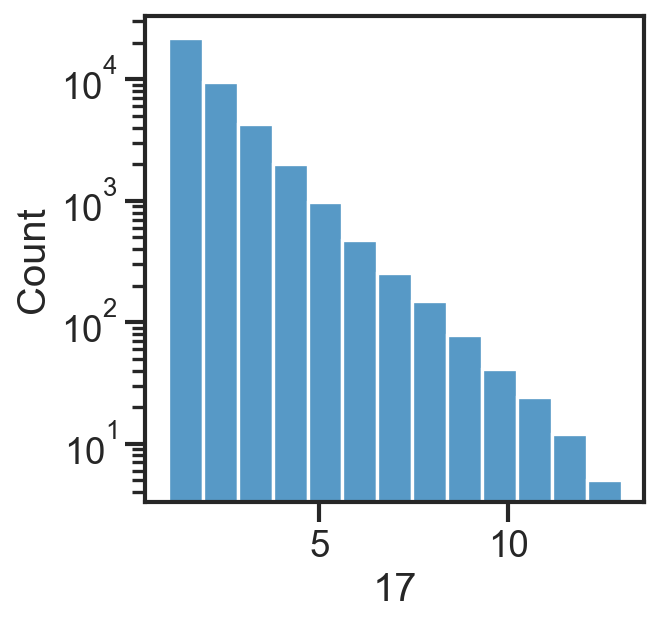

In [55]:
sns.histplot(tss_selection.loc[:,17], bins = 13, palette = 'magma',
            kde = False)

plt.yscale('log')

<AxesSubplot:xlabel='6', ylabel='Count'>

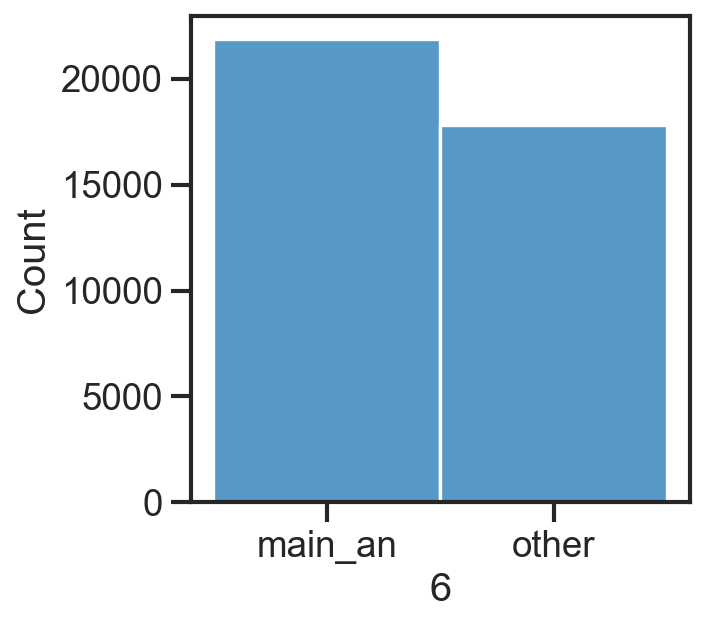

In [89]:
sns.histplot(tss_selection.loc[:,6], bins = 13, palette = 'magma',
            kde = False)

#plt.yscale('log')

In [13]:
df_k4 = pd.read_csv('../data/H3K4me3_Tiso_K4sel_5kb_counts.csv')


In [18]:
df_k4.index = df_k4['Unnamed: 0']


In [507]:
df_k4 = df_k4.drop('Unnamed: 0', axis = 1)

In [59]:
tss_selection.loc[:,17].max()

13

In [90]:
tss_main = tss_selection[tss_selection.loc[:,6] == 'main_an'].loc[:,3]
tss_other = tss_selection[tss_selection.loc[:,6] == 'other'].loc[:,3]




In [91]:
df_main = df_k4.loc[:,np.intersect1d(df_k4.columns,list(tss_main)).astype(str)]
df_other = df_k4.loc[:,np.intersect1d(df_k4.columns,list(tss_other)).astype(str)]


In [92]:
print(df_main.shape)
print(df_other.shape)

print(len(tss_main), len(np.intersect1d(df_main.columns,list(tss_main)).astype(str)))
print(len(tss_other), len(np.intersect1d(df_other.columns,list(tss_other)).astype(str)))


(25344, 21403)
(25344, 4961)
21869 21403
17832 4961


In [94]:
df_main.to_csv('../data/20231106_TSS_main.csv')

In [95]:
df_other.to_csv('../data/20231106_TSS_other.csv')

In [15]:
#from scipy import sparse, io

#sparse_df = io.mmread('../data/sparse_df_H3K4me3.mtx')


## dataframes

pseudotime

In [325]:
adata = sc.read_h5ad('../data/20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch2', 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'cellnames', 'bc', 'cellname', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_counts_stressgenes', 'n_genes', 'S_score', 'G2M_score', 'phase', 'histone_score', 'mark_binary', 'enrichment', 'coverage', 'QC', 'umap_density_mark', 'predicted_id_E75', 'predicted_id_E85', 'prediction_confidence_E75', 'prediction_confidence_E85', 'predicted_final', 'leiden', 'celltype', 'old_leiden_general', 'old_celltype', 'old_leiden_merge', 'umap_1D', 'umap_1D_rescale', 'celltype_general', 'lineage', 'lin_day', 'hour', 'PT1', 'PT2', 'PT1_avg', 'K4_total', 'K27_total', 'K4_total_log', 'K27_total_log', 'RNA_total_log'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_

In [487]:
pseudo = pd.DataFrame(adata.obs['PT1']).rename(columns={'PT1':'pseudotime'})
pseudo = pseudo[(adata.obs['lineage'] == 'Pluripotent')]
#pseudo = pseudo[adata.obs['celltype'] != 'PGCs']
pseudo = pseudo[adata.obs['celltype'] != 'Epidermis Progenitors']
pseudo = pseudo[adata.obs['celltype'] != 'Epiblast']
#pseudo = pseudo[adata.obs['celltype'] != 'Naive PGCs']
#pseudo = pseudo[adata.obs['celltype'] != 'Reprogramming PGCs']
#pseudo = pseudo[adata.obs['celltype'] != 'mESCs']

pseudo.head(2)

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_5281/178307938.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pseudo = pseudo[adata.obs['celltype'] != 'Epidermis Progenitors']
/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_5281/178307938.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pseudo = pseudo[adata.obs['celltype'] != 'Epiblast']


,pseudotime
index,
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_205,19.679937
PZ-MB-TChIC-Gastd5-rep2-H3K27me3-1_34,26.785284


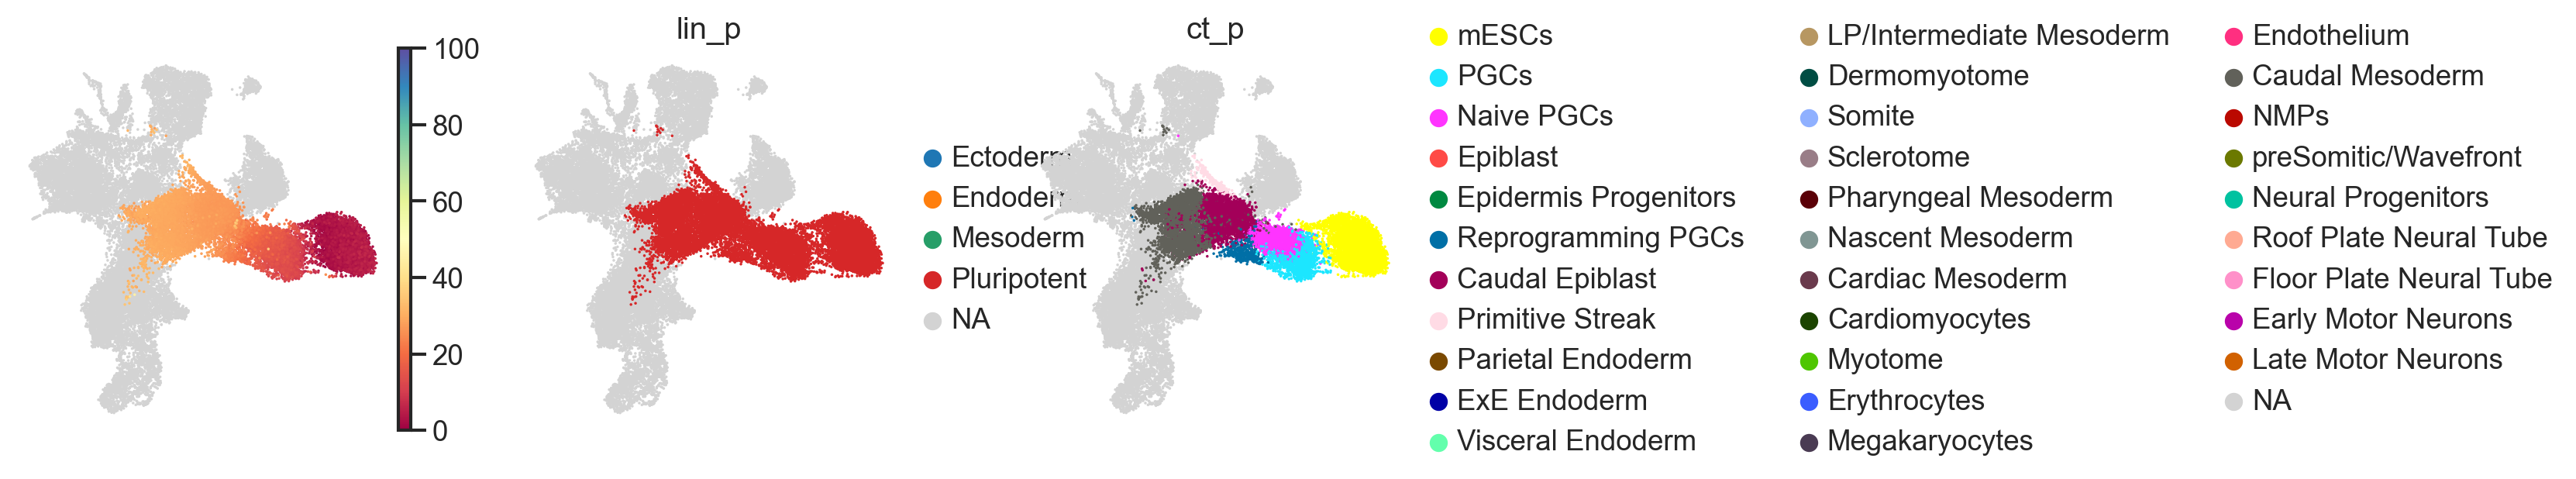

In [488]:
adata.obs['pseudo_p'] = adata.obs.loc[pseudo.index]['PT1']
adata.obs['lin_p'] = adata.obs.loc[pseudo.index]['lineage']
adata.obs['ct_p'] = adata.obs.loc[pseudo.index]['celltype']
sc.pl.umap(adata,color = ['pseudo_p','lin_p','ct_p'], frameon = False, cmap = 'Spectral',size = 10, vmin = 0, vmax = 100, title = '')

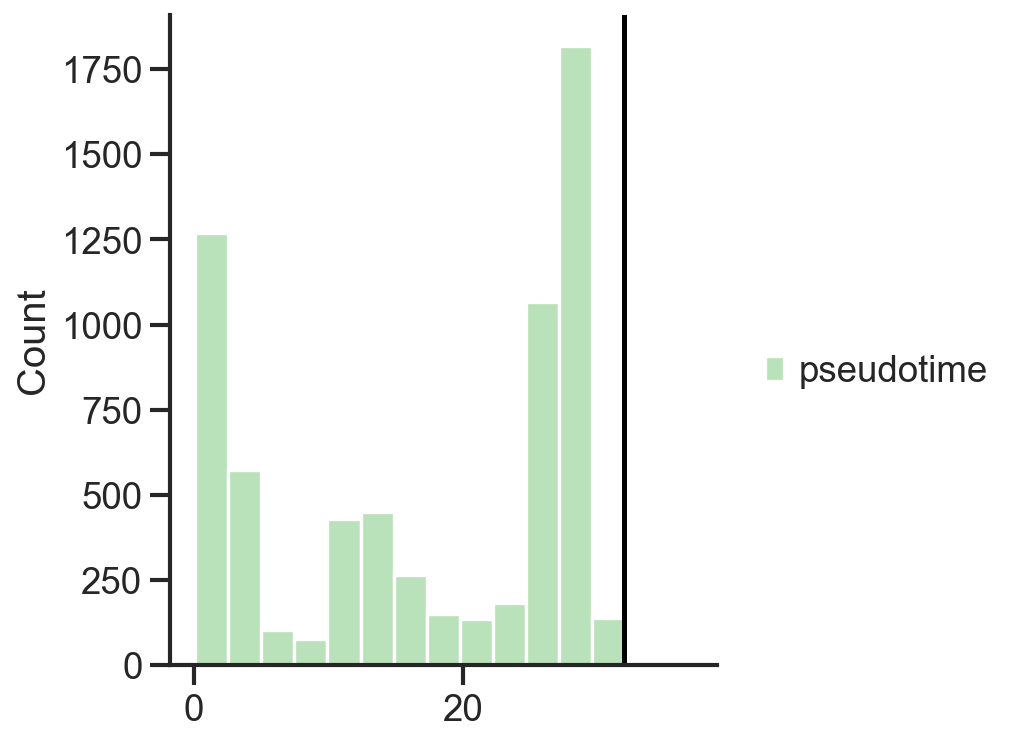

In [489]:
sns.displot(pseudo[(pseudo.index).str.contains('H3K4')], palette = 'Greens_r')
plt.axvline(32,c='black')
plt.show()

In [490]:
pseudo = pseudo.loc[pseudo['pseudotime'] < 32]

## make binned table

In [491]:
steps = 100

In [492]:
pseudo['hour'] = adata.obs['hour']
pseudo = pseudo[(pseudo['hour'] == 'mESCs') | (pseudo['hour'] == '72h') | (pseudo['hour'] == '96h') | (pseudo['hour'] == '120h')]

In [509]:
common_barcodes = np.intersect1d(df_k4.index,pseudo.index).astype(str)

df_all_tss_f = df_k4.loc[common_barcodes]
pseudo_f = pseudo.loc[common_barcodes]

In [514]:
df_all_tss_f[['pseudotime','hour']] = pseudo[['pseudotime','hour']]

In [516]:
b_pseudo_all, b_all, b_all_sum = bintable(df_all_tss_f, steps)


In [520]:
b_norm = b_all/np.percentile(b_all, 99)


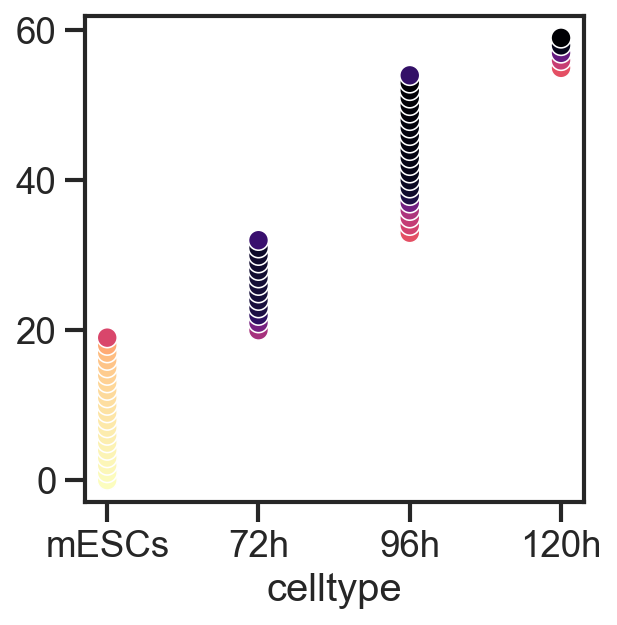

In [519]:
sns.scatterplot(x = b_pseudo_all['celltype'], y = b_pseudo_all.index, hue = b_pseudo_all['pseudotime'], palette = 'magma_r')
plt.legend([],frameon=False)

In [106]:
from scipy import stats

In [521]:
# rna, mean 2.5, 
# k4, mean 1.2,
# k27, mean 3.5,
k4_ttest = gene_ttest(b_all_sum, mean = 1.2, fold = 1.5, pv = 2.3, cutoff = 10)


In [524]:
k4_ttest[['gene','promoter']] = [ob.split(':') for ob in k4_ttest.index]

In [525]:
k4_ttest

,fold,p,state,mean,gene,promoter
Gm47752:1,-0.832193,1.171032,0,0.906785,Gm47752,1
Syngr1:1,-1.352258,4.534868,1,3.116003,Syngr1,1
Syngr1:2,-1.648111,4.036602,3,2.105433,Syngr1,2
Syngr1:3,-2.000960,4.485572,3,1.649665,Syngr1,3
Atad5:1,-0.350467,1.272664,1,3.798519,Atad5,1
...,...,...,...,...,...,...
Cd53:1,-0.100000,0.480743,0,0.050000,Cd53,1
Rtl3:1,-0.058496,0.075793,0,0.329248,Rtl3,1
Sdf2l1:1,-0.617122,1.415869,1,3.332803,Sdf2l1,1
Ifi211:1,0.000000,1.000000,0,0.000000,Ifi211,1


In [526]:
k4_ttest.to_csv('../data/20231207_k4me3_all_ttest.csv')


# QC plots

In [527]:
sc.set_figure_params(dpi=80)
sns.set_style('white')
sns.set_context('talk')
sns.set_style('ticks')

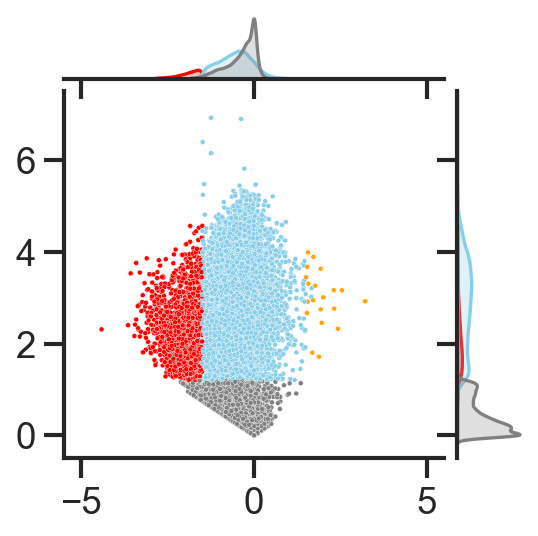

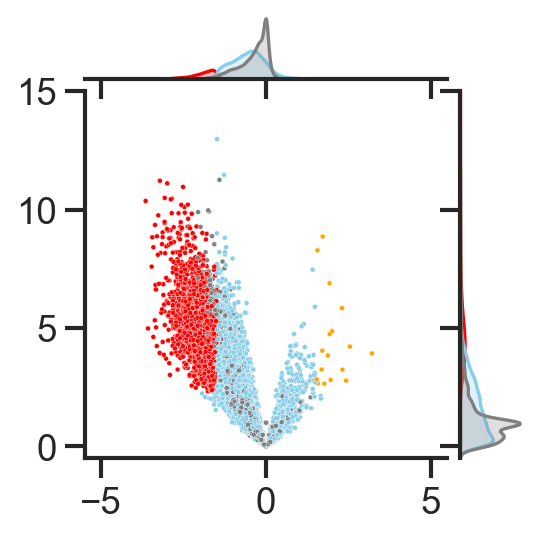

In [534]:
#"scatter" (default), "kde", "hist", "hex", "reg" and "resid".

# all!
kdeplot = sns.jointplot(data = k4_ttest,
               x = 'fold',s = 5,
               y = 'mean', kind = 'scatter', 
                        hue = 'state', palette = cols,
                        xlim = [-5.5,5.5], ylim = [-0.5,7.5],
              height = 4, 
              color = Purple)
kdeplot.set_axis_labels('', '', fontsize=16)
kdeplot.ax_joint.legend([], frameon = False)


kdeplot = sns.jointplot(data = k4_ttest,
               x = 'fold',s = 5,
               y = 'p', kind = 'scatter', 
                        hue = 'state', palette = cols,
                        xlim = [-5.5,5.5], ylim = [-0.5,15],
              height = 4, 
              color = Purple)
kdeplot.set_axis_labels('', '', fontsize=16)
kdeplot.ax_joint.legend([], frameon = False)

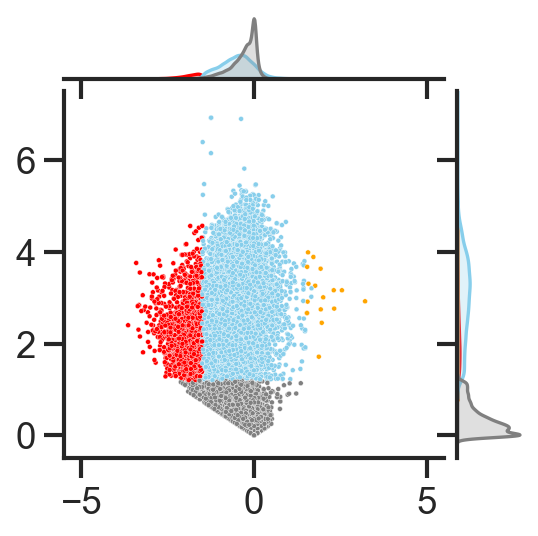

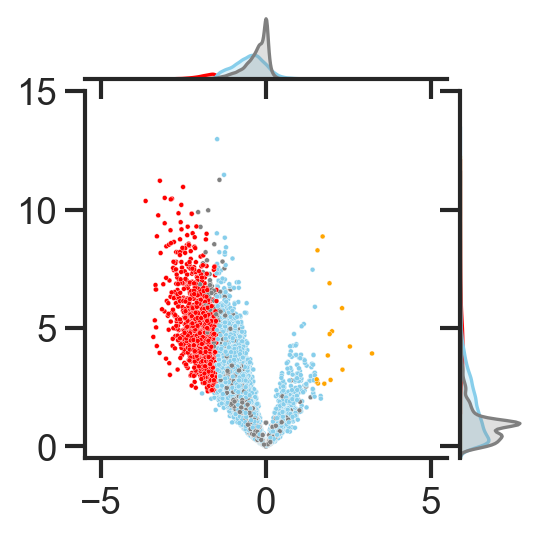

In [539]:
#"scatter" (default), "kde", "hist", "hex", "reg" and "resid".

# TSS1
TSS1 = k4_ttest[k4_ttest['promoter'] == '1']

kdeplot = sns.jointplot(data = TSS1,
               x = 'fold',s = 5,
               y = 'mean', kind = 'scatter', 
                        hue = 'state', palette = cols,
                        xlim = [-5.5,5.5], ylim = [-0.5,7.5],
              height = 4, 
              color = Purple)
kdeplot.set_axis_labels('', '', fontsize=16)
kdeplot.ax_joint.legend([], frameon = False)


kdeplot = sns.jointplot(data = TSS1,
               x = 'fold',s = 5,
               y = 'p', kind = 'scatter', 
                        hue = 'state', palette = cols,
                        xlim = [-5.5,5.5], ylim = [-0.5,15],
              height = 4, 
              color = Purple)
kdeplot.set_axis_labels('', '', fontsize=16)
kdeplot.ax_joint.legend([], frameon = False)

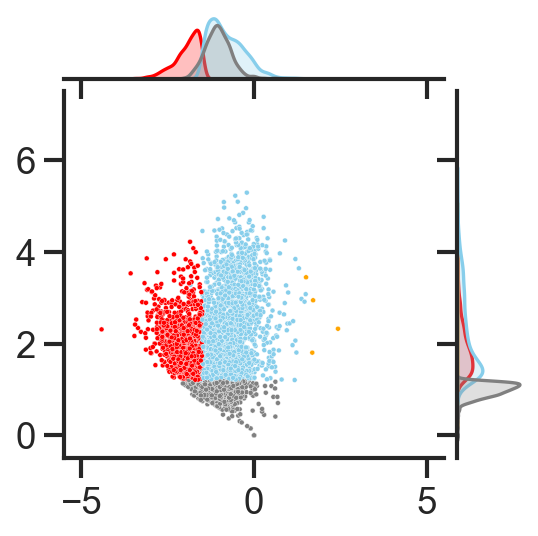

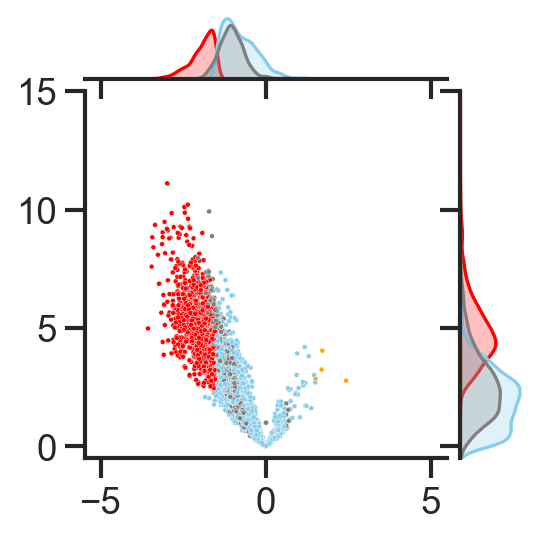

In [540]:
#"scatter" (default), "kde", "hist", "hex", "reg" and "resid".

# alt. TSS
aTSS = k4_ttest[k4_ttest['promoter'] != '1']

kdeplot = sns.jointplot(data = aTSS,
               x = 'fold',s = 5,
               y = 'mean', kind = 'scatter', 
                        hue = 'state', palette = cols,
                        xlim = [-5.5,5.5], ylim = [-0.5,7.5],
              height = 4, 
              color = Purple)
kdeplot.set_axis_labels('', '', fontsize=16)
kdeplot.ax_joint.legend([], frameon = False)


kdeplot = sns.jointplot(data = aTSS,
               x = 'fold',s = 5,
               y = 'p', kind = 'scatter', 
                        hue = 'state', palette = cols,
                        xlim = [-5.5,5.5], ylim = [-0.5,15],
              height = 4, 
              color = Purple)
kdeplot.set_axis_labels('', '', fontsize=16)
kdeplot.ax_joint.legend([], frameon = False)

Text(0.5, 1.0, 'alternative TSS')

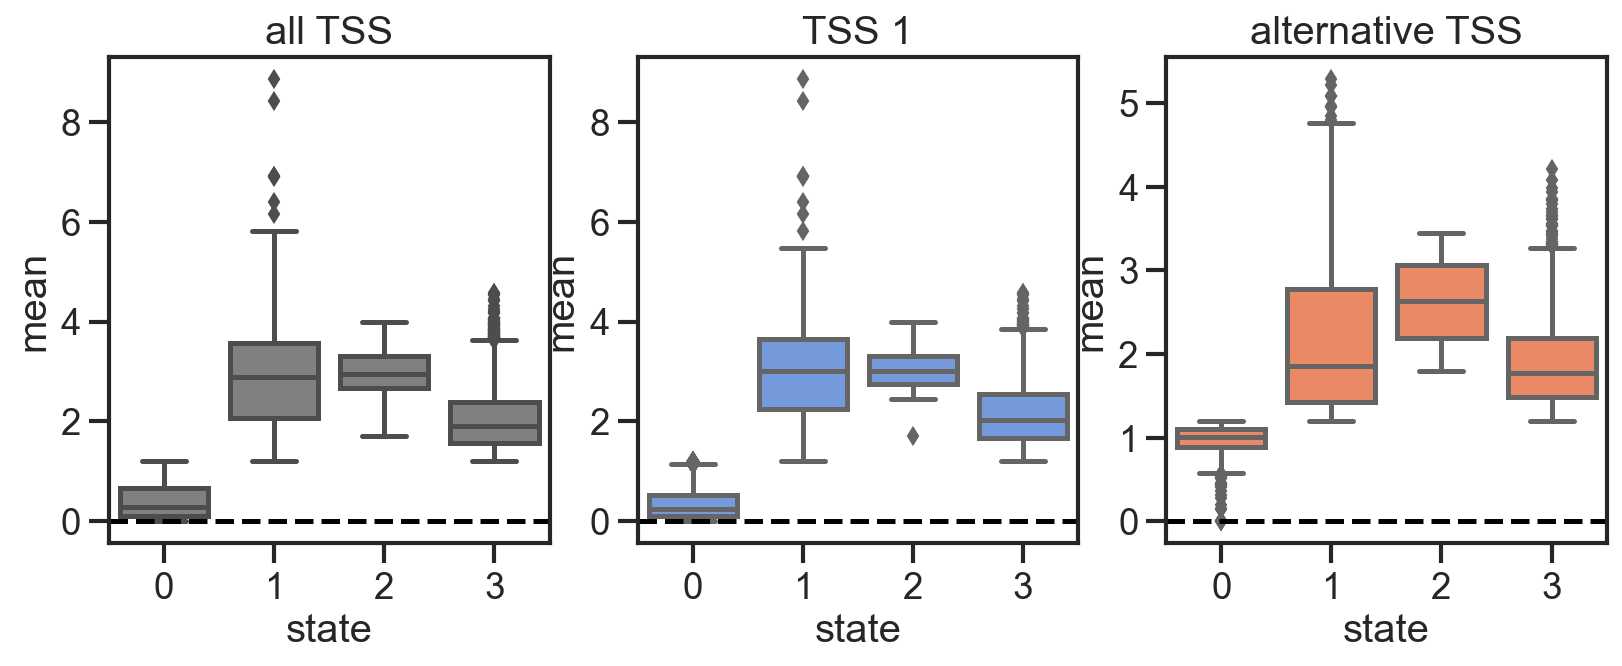

In [554]:
fig, ax = plt.subplots(1,3,figsize = (12,4))

sns.boxplot(x = k4_ttest['state'].round(1),ax=ax[0], color = 'grey',
           y = k4_ttest['mean'])
ax[0].axhline(0,ls = '--', color = 'black')
ax[0].set_title('all TSS')

sns.boxplot(x = TSS1['state'].round(1),ax=ax[1], color = 'cornflowerblue',
           y = TSS1['mean'])
ax[1].axhline(0,ls = '--', color = 'black')
ax[1].set_title('TSS 1')

sns.boxplot(x = aTSS['state'].round(1),ax=ax[2], color = 'coral',
           y = aTSS['mean'])
ax[2].axhline(0,ls = '--', color = 'black')
ax[2].set_title('alternative TSS')

# states plots

In [56]:
import matplotlib.patches as mpatches

In [567]:
states_test = k4_ttest.pivot('gene','promoter', values='state').drop('1.1', axis = 1)

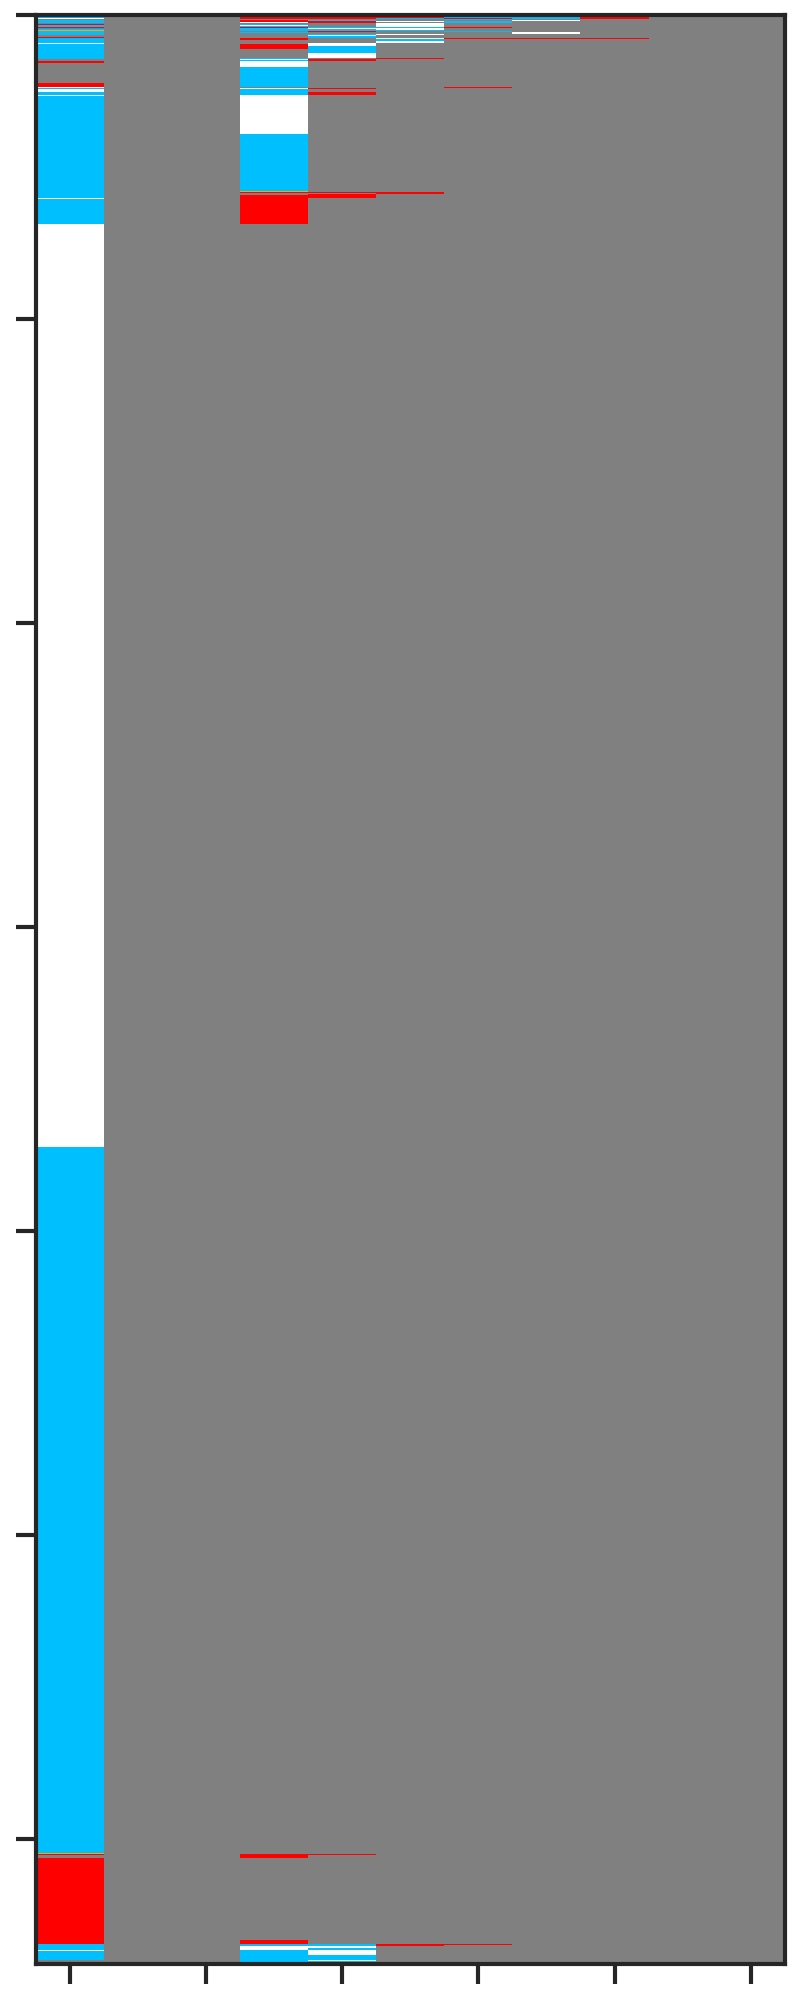

In [581]:
makeStatesPlot(states_test)

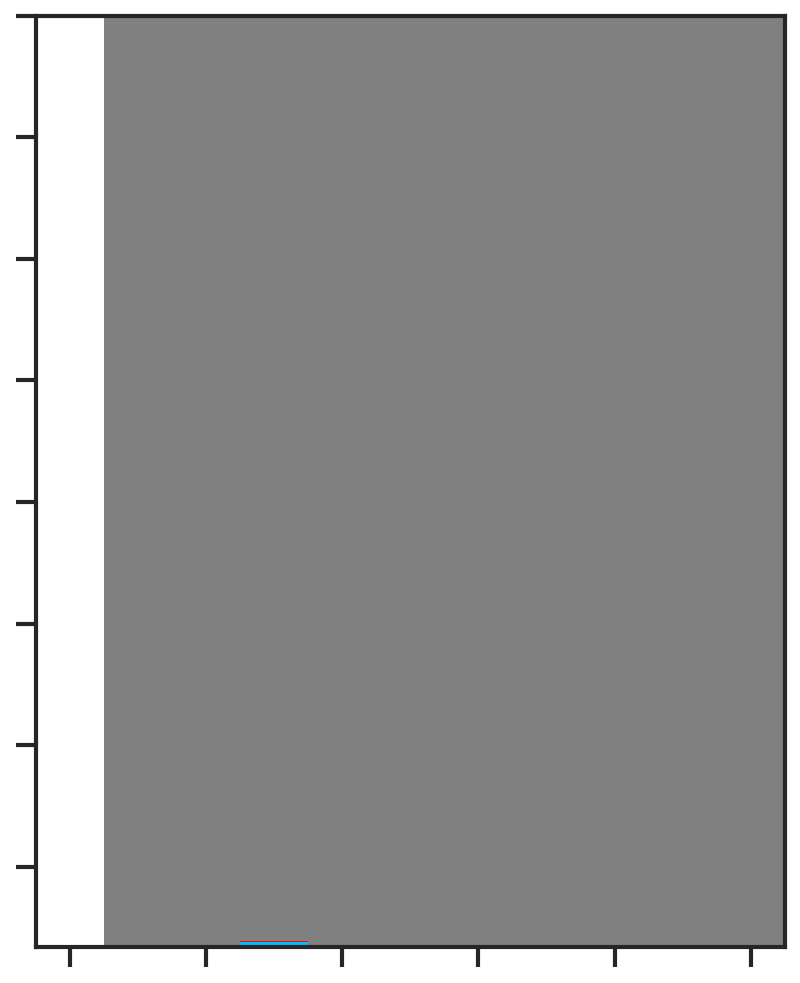

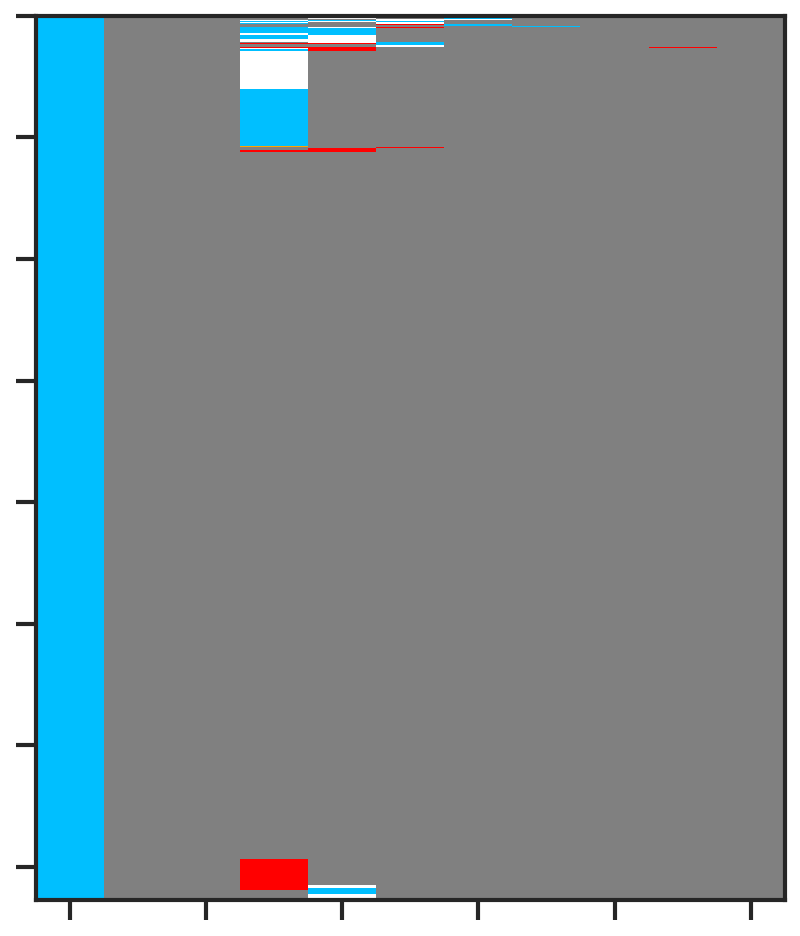

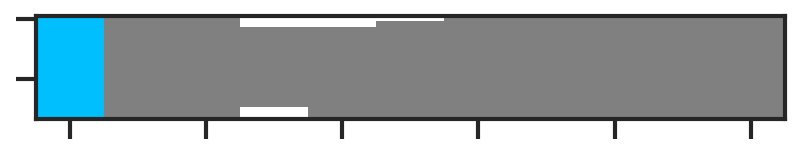

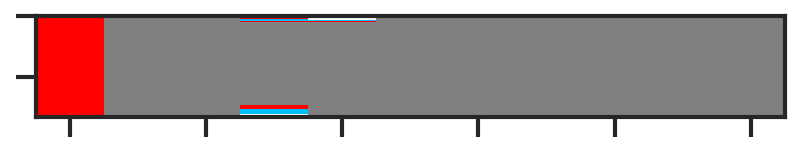

In [585]:
makeStatesPlot(states_test[states_test['1'] == 0], aspect_ratio = 0.0005)
makeStatesPlot(states_test[states_test['1'] == 1])
makeStatesPlot(states_test[states_test['1'] == 2], aspect_ratio = 0.05)
makeStatesPlot(states_test[states_test['1'] == 3])

## heatmap plot over pseudotime

In [1]:
#states_plot.replace({'neg':0,'down':1,'up':2,'pos':3})

,fold,p,state,mean
0610009B22Rik:1,-0.100000,0.254937,0,0.150000
0610010F05Rik:1,-0.375489,0.906623,1,2.053922
0610010K14Rik:1,-0.154444,0.642516,1,4.282401
0610012G03Rik:1,-0.702946,3.280970,1,3.852772
0610030E20Rik:1,-0.476635,1.383467,1,3.204016
...,...,...,...,...
mt-Nd3:1,-0.903539,5.779998,1,5.074486
mt-Nd4:1,-0.573850,2.960557,1,5.916448
mt-Nd4l:1,-0.463843,2.203803,1,5.756037
mt-Nd5:1,-0.733811,4.251700,1,6.771523


In [179]:
states_sorted

,main_state,other_state
Zscan10,3,3
Zfp704,3,3
Zfp64,3,3
Zfp532,3,3
Zfp458,3,3
...,...,...
6430548M08Rik,1,0
6330409D20Rik,1,0
3110001I22Rik,1,0
1110051M20Rik,1,0


In [588]:
states_plot

promoter,1,2
gene,,
0610005C13Rik,3.0,NaN
0610006L08Rik,0.0,NaN
0610009B22Rik,0.0,NaN
0610009E02Rik,1.0,NaN
0610009L18Rik,0.0,NaN
...,...,...
mt-Nd3,1.0,NaN
mt-Nd4,1.0,NaN
mt-Nd4l,1.0,NaN


In [ ]:
states = states_test[['1','2']]
states = states.fillna(4)
aspect_ratio = 0.0005

states_plot = states.replace({'neg':0,'pos':1,'up':2,'down':3, 'missing':4})#[states['k27_state'] == 3]
order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(pd.DataFrame(states_plot[['1','2']])))
states_sorted = states_plot.iloc[order]

genes = list(states_sorted.index)

plot_df1 = pd.concat([b_all[genes], b_pseudo_all], axis=1)
plot_df1['binned'] = (plot_df1['pseudotime']).astype(int)
plot_df1.index = plot_df1['pseudotime']
plot_df1 = plot_df1.drop(columns = ['pseudotime','binned'])


#plot_df2 = pd.concat([b_other[genes], b_pseudo_other], axis=1)
#plot_df2['binned'] = (plot_df2['pseudotime']).astype(int)
#plot_df2.index = plot_df2['pseudotime']
#plot_df2 = plot_df2.drop(columns = ['pseudotime','binned'])




[]

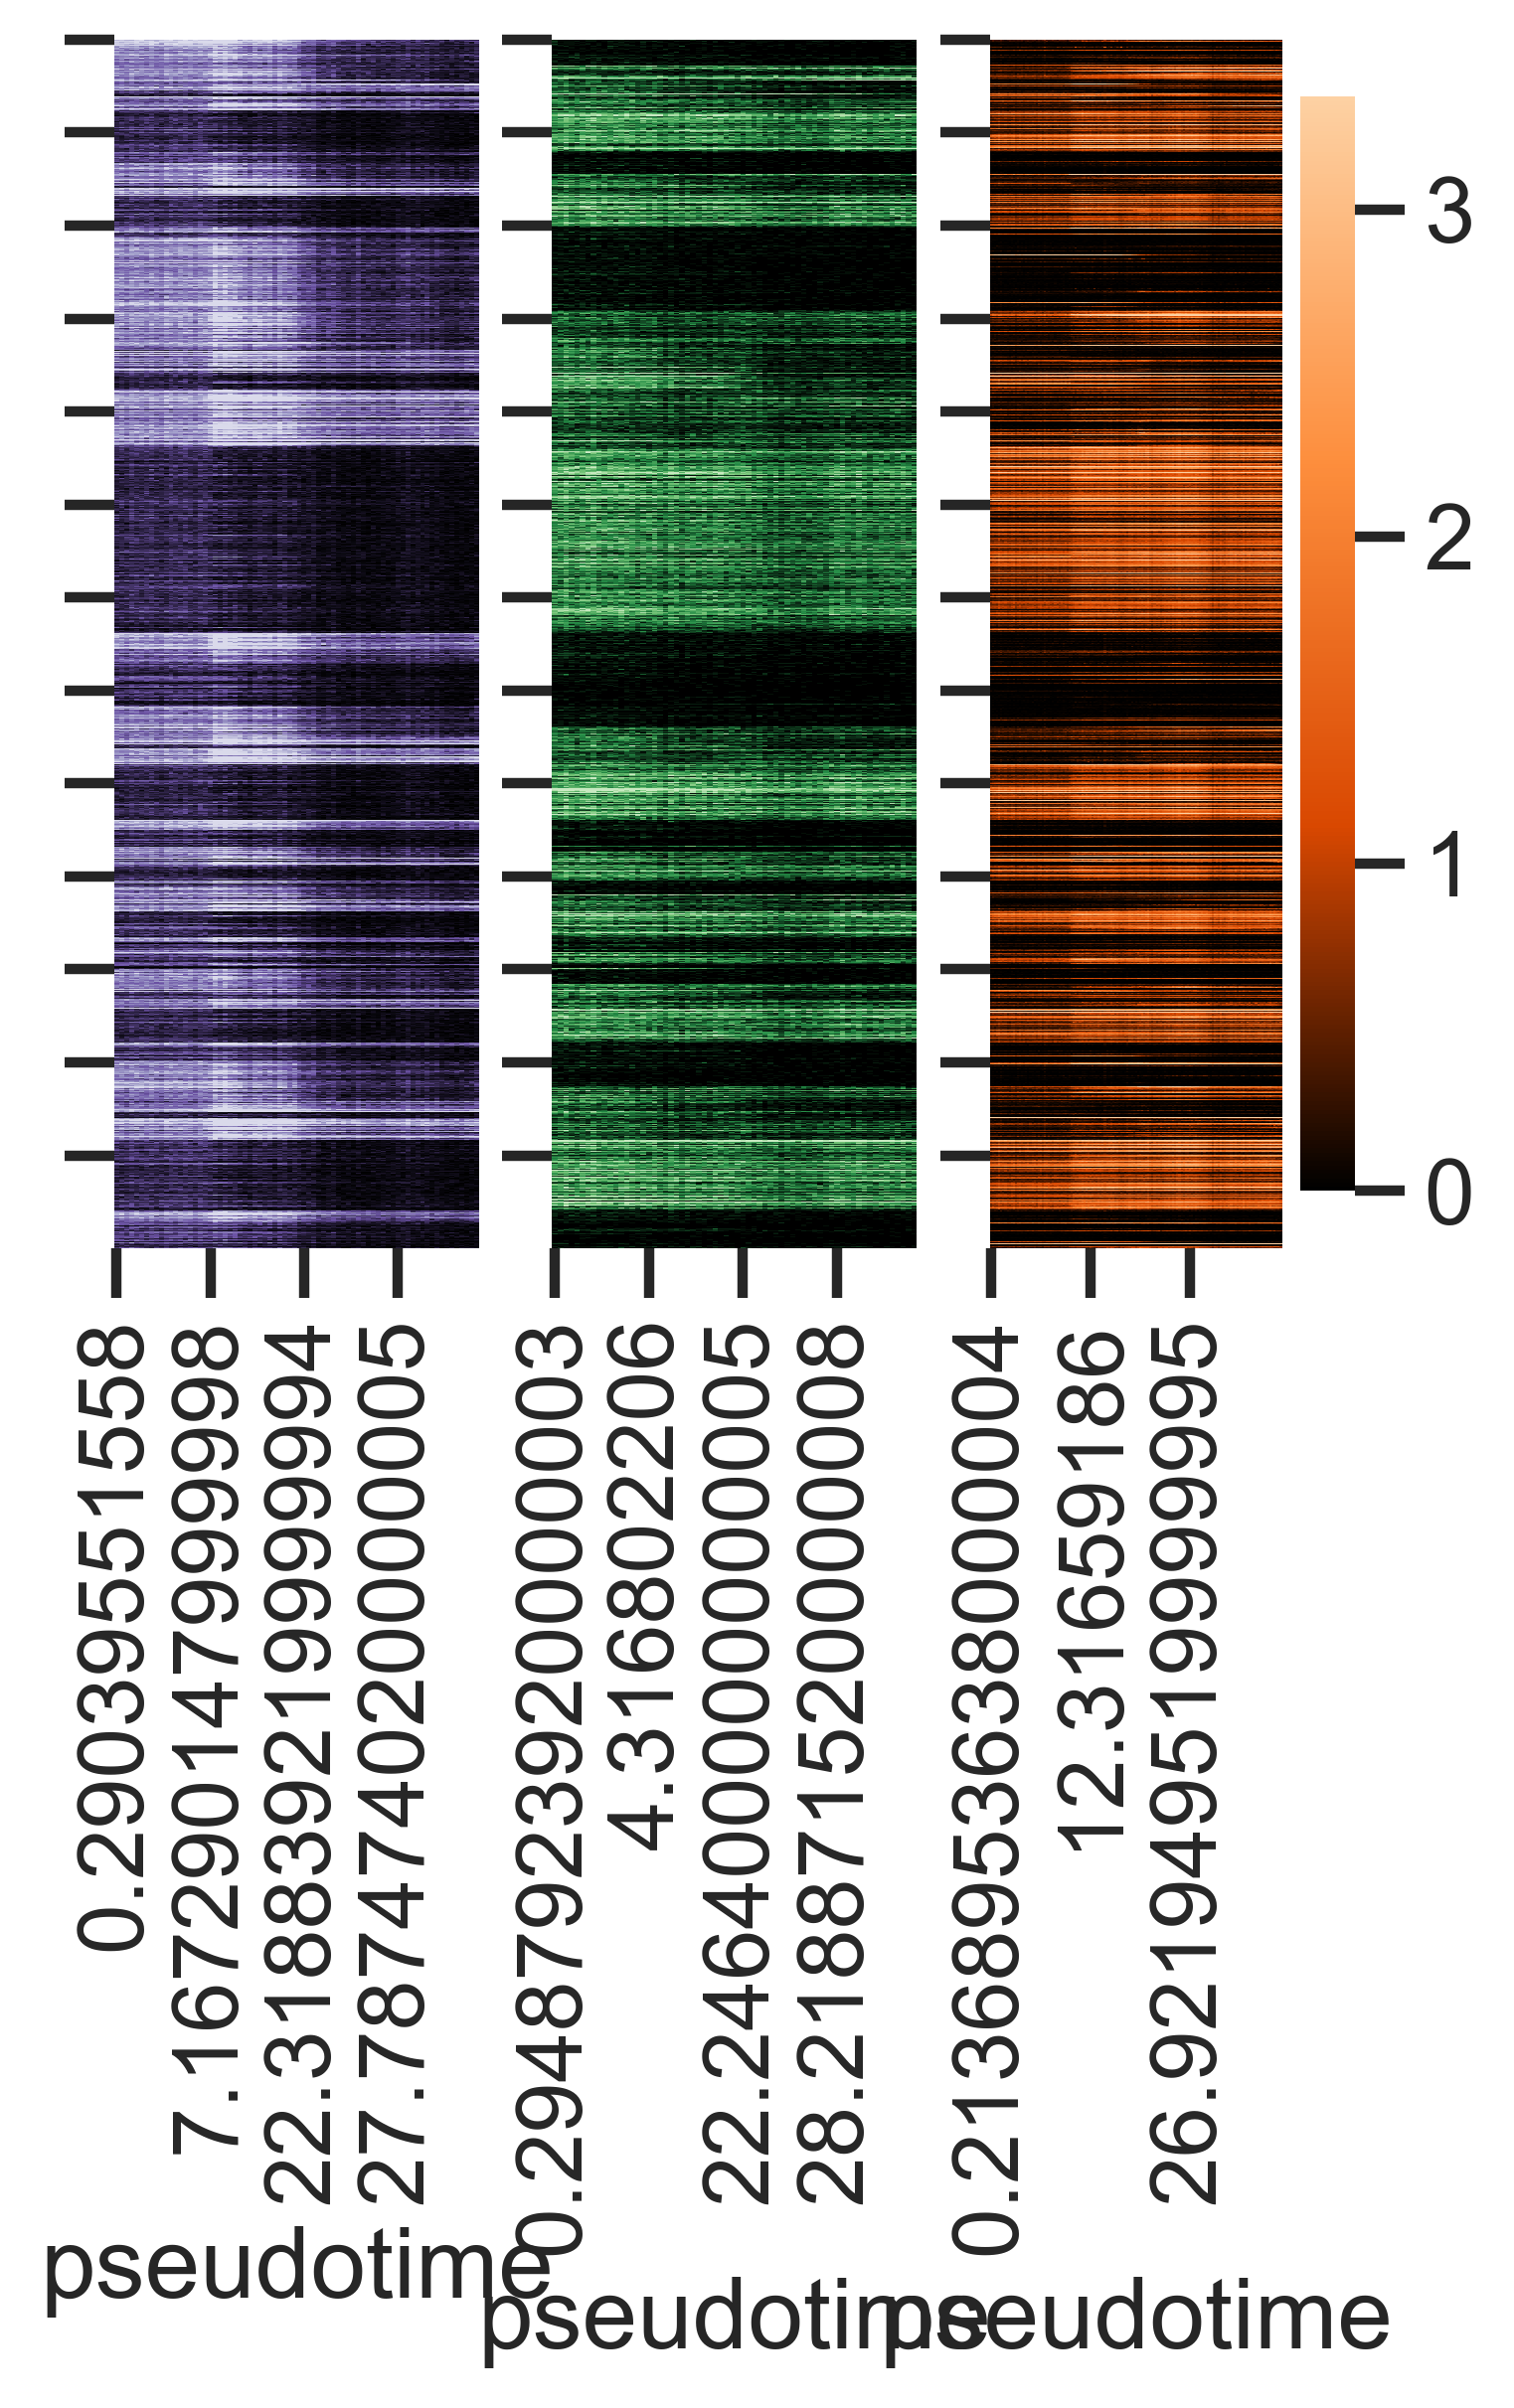

In [65]:
fig,ax = plt.subplots(1,2,figsize = (4,4))

ax[0] = sns.heatmap(plot_df1.T.iloc[order], cmap = greens_r,ax=ax[0], 
                    cbar = False, vmax = np.percentile(plot_df1,99))
ax[1] = sns.heatmap(plot_df2.T.iloc[order], cmap = greens_r,ax=ax[1], 
                    cbar = False, vmax = np.percentile(plot_df2,99))


ax[0].set_yticklabels([])
ax[1].set_yticklabels([])
ax[1].set_ylabel('')
plt.plot()





In [67]:
states = states[['k27_state','k4_state','rna_state']]
aspect_ratio = 0.0005

states_plot = states.replace({'neg':0,'pos':1,'up':2,'down':4})#[states['k27_state'] == 3]
order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(pd.DataFrame(states_plot[['k27_state','k4_state']])))
states_sorted = states_plot.iloc[order]

genes = list(states_sorted.index)

plot_df1 = pd.concat([b_k27[genes], b_pseudo_k27], axis=1)
plot_df1['binned'] = (plot_df1['pseudotime']).astype(int)
plot_df1.index = plot_df1['pseudotime']
plot_df1 = plot_df1.drop(columns = ['pseudotime','binned'])


plot_df2 = pd.concat([b_k4[genes], b_pseudo_k4], axis=1)
plot_df2['binned'] = (plot_df2['pseudotime']).astype(int)
plot_df2.index = plot_df2['pseudotime']
plot_df2 = plot_df2.drop(columns = ['pseudotime','binned'])

plot_df3 = pd.concat([np.log2(b_rna+1)[genes], b_pseudo_rna], axis=1)
plot_df3['binned'] = (plot_df3['pseudotime']).astype(int)
plot_df3.index = plot_df3['pseudotime']
plot_df3 = plot_df3.drop(columns = ['pseudotime','binned'])




## lineplots of all layers

In [180]:
states = df_all[['main_state','other_state']]

In [69]:
#states_biv = states[(states['k_state'] != 0) & (states['k4_state'] != 0)]


## states line plots

In [122]:
def plotHeatmap(genes, cbar = True, sort_order = 'k4_state'):
    sns.set_context('talk')
    sns.set_style('white')
    states_plot = df_all.loc[genes,['k27_state','k4_state']]
    
    #order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(pd.DataFrame(states_plot[sort_order])))
    #states_sorted = states_plot.iloc[order]

    genes = list(states_sorted.index)

    plot_df1 = pd.concat([b_k27[genes], b_pseudo_k27], axis=1)
    plot_df1['binned'] = (plot_df1['pseudotime']).astype(int)
    plot_df1.index = plot_df1['binned']
    plot_df1 = plot_df1.drop(columns = ['pseudotime','binned'])


    plot_df2 = pd.concat([b_k4[genes], b_pseudo_k4], axis=1)
    plot_df2['binned'] = (plot_df2['pseudotime']).astype(int)
    plot_df2.index = plot_df2['binned']
    plot_df2 = plot_df2.drop(columns = ['pseudotime','binned'])

    plot_df3 = pd.concat([np.log2(b_rna+1)[genes], b_pseudo_rna], axis=1)
    plot_df3['binned'] = (plot_df3['pseudotime']).astype(int)
    plot_df3.index = plot_df3['binned']
    plot_df3 = plot_df3.drop(columns = ['pseudotime','binned'])


    fig,ax = plt.subplots(3,1,figsize = (8,5))

    ax[0] = sns.heatmap(plot_df1.T.#.iloc[order], 
                        cmap = purples_r,ax=ax[0], 
                        cbar = cbar, vmax = 0.52)
    ax[1] = sns.heatmap(plot_df2.T,#.iloc[order], 
                        cmap = greens_r,ax=ax[1], 
                        cbar = cbar, vmax = 0.22)
    ax[2] = sns.heatmap(plot_df3.T,#.iloc[order], 
                        cmap = oranges_r,ax=ax[2], 
                        cbar = cbar, vmax = 3)

    ax[0].set_xticklabels([])
    ax[1].set_xticklabels([])
    ax[2].set_xticklabels([])

    ax[0].set_yticklabels([])
    ax[1].set_yticklabels([])
    ax[2].set_yticklabels([])
    ax[0].set_ylabel('H3K27me3')
    ax[1].set_ylabel('H3K4me3')
    ax[2].set_ylabel('RNA')
    ax[2].set_xlabel('pseudotime')
    plt.plot()
    plt.show()

allgenes = list(states.index)
def makeGO(genes, background = allgenes, num = 10, figsize = (4,2)):
    go = sc.queries.enrich({'cluster':genes,'all':background}, org="mmusculus")

    plotcl = go
    cluster = 'cluster'

    plot1 = plotcl[plotcl['query'] == cluster][plotcl[plotcl['query'] == cluster]['source'] == 'GO:BP'].sort_values(by='p_value')[['name','p_value']][0:num]
    plot1['-log (p-value)'] = np.log10(plot1['p_value'])*-1
    sns.set_style('ticks')
    sns.set_context('talk')
    fig,ax = plt.subplots(figsize = figsize)
    ax = sns.barplot(y=plot1['name'],x=plot1['-log (p-value)'], color = 'grey')
    ax.set_ylabel('')
    plt.show()
